# Deep Networks with Stochastic Depth

Huang, Sun, Liu, Sedra, Weinberger — ECCV 2016. [Paper PDF](Deep%20Networks%20with%20Stochastic%20Depth.pdf)

**The problem:** very deep ResNets are slow to train and can suffer from vanishing gradients
and diminishing feature reuse, even with residual connections.

**The idea:** during training, randomly drop entire residual blocks — replace them with a pure
identity passthrough — instead of always computing them. Each block $l$ gets a Bernoulli "survival"
gate $b_l \sim \text{Bernoulli}(p_l)$:

$$H_l = \text{ReLU}\big(\text{id}(x) + b_l \cdot f_l(x)\big) \quad \text{(training)}$$

When $b_l = 0$, $f_l$ (the conv branch) isn't computed at all — a real compute saving, not just a
masked-out term. At test time, every block runs, but its branch is rescaled by its survival
probability so the expected output matches training:

$$H_l = \text{ReLU}\big(\text{id}(x) + p_l \cdot f_l(x)\big) \quad \text{(eval)}$$

**The schedule:** survival probability decays linearly with depth — early blocks are almost
always kept, deep blocks are dropped often:

$$p_l = 1 - \frac{l}{L}(1 - p_L), \quad l = 1, \dots, L$$

with $p_L = 0.5$ in the paper's default. This gives three effects: faster training (skipped
compute), an implicit ensemble/regularization effect, and better gradient flow in very deep nets.

This notebook implements the mechanism from scratch (see `model.py`, `train.py`) and trains a
small 18-block CIFAR ResNet two ways — a plain baseline and a stochastic-depth version — to make
the effect visible without the paper's original compute budget (ResNet-110+, hundreds of epochs).

In [1]:
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset

from model import ResNetCIFAR, survival_probabilities
from train import evaluate, train_one_epoch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## The survival probability schedule

Before training anything, let's look at the schedule itself: 18 blocks (3 stages × 6 blocks),
linear decay from near-1 down to 0.5.

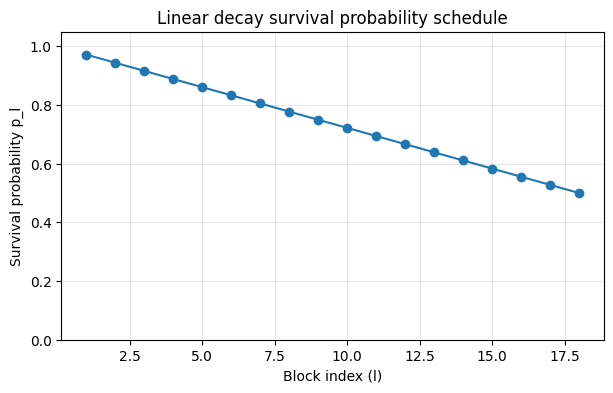

In [2]:
probs = survival_probabilities(num_blocks=18, p_L=0.5)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 19), probs, marker="o")
plt.xlabel("Block index (l)")
plt.ylabel("Survival probability p_l")
plt.title("Linear decay survival probability schedule")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

## CIFAR-10 data

Standard augmentation: random crop with padding, horizontal flip, normalization. Loaded via the
Hugging Face `datasets` library (fast CDN-backed download, cached under `~/.cache/huggingface`)
rather than torchvision's direct download, which points at a very slow origin server.

In [3]:
normalize = transforms.Normalize(
    mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize,
])
test_transform = transforms.Compose([transforms.ToTensor(), normalize])

hf_cifar10 = load_dataset("uoft-cs/cifar10")


class HFCifar10Dataset(Dataset):
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        example = self.hf_split[idx]
        image = self.transform(example["img"].convert("RGB"))
        return image, example["label"]


train_set = HFCifar10Dataset(hf_cifar10["train"], train_transform)
test_set = HFCifar10Dataset(hf_cifar10["test"], test_transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)} images, Test: {len(test_set)} images")

Train: 50000 images, Test: 10000 images


## Training both models

Same architecture, same optimizer settings, same schedule — the only difference is whether
stochastic depth is on. SGD with momentum, step LR decay, 80 epochs.

In [4]:
def run_training(stochastic_depth: bool, epochs: int = 80):
    torch.manual_seed(0)
    net = ResNetCIFAR(blocks_per_stage=6, p_L=0.5, stochastic_depth=stochastic_depth).to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[40, 60], gamma=0.1)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "epoch_time": []}
    for epoch in range(epochs):
        train_stats = train_one_epoch(net, train_loader, optimizer, device)
        test_stats = evaluate(net, test_loader, device)
        scheduler.step()
        history["train_loss"].append(train_stats["loss"])
        history["train_acc"].append(train_stats["accuracy"])
        history["test_loss"].append(test_stats["loss"])
        history["test_acc"].append(test_stats["accuracy"])
        history["epoch_time"].append(train_stats["time_seconds"])
        print(
            f"[{'SD' if stochastic_depth else 'baseline'}] epoch {epoch + 1}/{epochs} "
            f"train_acc={train_stats['accuracy']:.3f} test_acc={test_stats['accuracy']:.3f} "
            f"time={train_stats['time_seconds']:.1f}s"
        )

    os.makedirs("results", exist_ok=True)
    tag = "sd" if stochastic_depth else "baseline"
    with open(f"results/{tag}_history.json", "w") as f:
        json.dump(history, f)

    return net, history


baseline_net, baseline_history = run_training(stochastic_depth=False)

[baseline] epoch 1/80 train_acc=0.304 test_acc=0.400 time=31.4s


[baseline] epoch 2/80 train_acc=0.467 test_acc=0.532 time=30.8s


[baseline] epoch 3/80 train_acc=0.577 test_acc=0.545 time=30.8s


[baseline] epoch 4/80 train_acc=0.657 test_acc=0.616 time=52.4s


[baseline] epoch 5/80 train_acc=0.718 test_acc=0.685 time=31.0s


...

[baseline] epoch 76/80 train_acc=0.991 test_acc=0.917 time=33.9s


[baseline] epoch 77/80 train_acc=0.990 test_acc=0.916 time=33.7s


[baseline] epoch 78/80 train_acc=0.991 test_acc=0.916 time=34.1s


[baseline] epoch 79/80 train_acc=0.991 test_acc=0.917 time=33.8s


[baseline] epoch 80/80 train_acc=0.992 test_acc=0.918 time=33.9s


In [5]:
sd_net, sd_history = run_training(stochastic_depth=True)

[SD] epoch 1/80 train_acc=0.266 test_acc=0.368 time=27.9s


[SD] epoch 2/80 train_acc=0.421 test_acc=0.497 time=27.7s


[SD] epoch 3/80 train_acc=0.506 test_acc=0.505 time=28.1s


[SD] epoch 4/80 train_acc=0.565 test_acc=0.587 time=27.7s


[SD] epoch 5/80 train_acc=0.609 test_acc=0.637 time=27.5s


...

[SD] epoch 76/80 train_acc=0.919 test_acc=0.901 time=27.4s


[SD] epoch 77/80 train_acc=0.923 test_acc=0.901 time=28.7s


[SD] epoch 78/80 train_acc=0.919 test_acc=0.903 time=28.3s


[SD] epoch 79/80 train_acc=0.919 test_acc=0.902 time=26.6s


[SD] epoch 80/80 train_acc=0.920 test_acc=0.903 time=27.1s


## Results

Four views of the same two training runs: accuracy curves, per-epoch training time, a summary
table, and the stochastic-depth block-activity pattern itself.

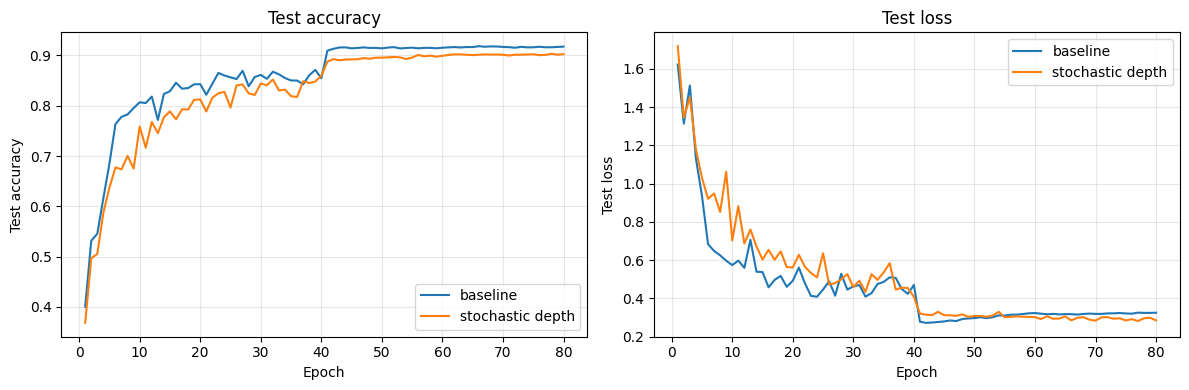

In [6]:
epochs_range = range(1, len(baseline_history["test_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, baseline_history["test_acc"], label="baseline")
axes[0].plot(epochs_range, sd_history["test_acc"], label="stochastic depth")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Test accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, baseline_history["test_loss"], label="baseline")
axes[1].plot(epochs_range, sd_history["test_loss"], label="stochastic depth")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Test loss")
axes[1].set_title("Test loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

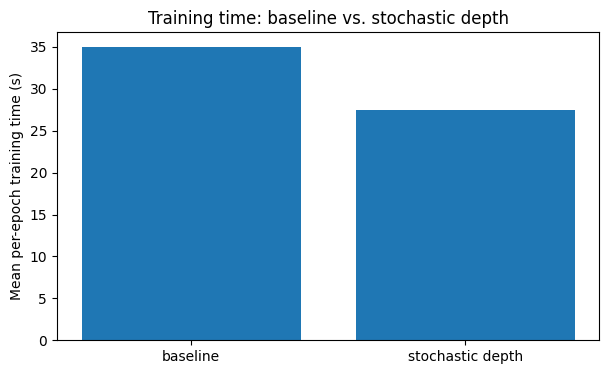

In [7]:
plt.figure(figsize=(7, 4))
plt.bar(
    ["baseline", "stochastic depth"],
    [np.mean(baseline_history["epoch_time"]), np.mean(sd_history["epoch_time"])],
)
plt.ylabel("Mean per-epoch training time (s)")
plt.title("Training time: baseline vs. stochastic depth")
plt.show()

In [8]:
print(f"{'Model':<20}{'Final test acc':<18}{'Total train time (s)':<22}")
print(
    f"{'baseline':<20}{baseline_history['test_acc'][-1]:<18.3f}"
    f"{sum(baseline_history['epoch_time']):<22.1f}"
)
print(
    f"{'stochastic depth':<20}{sd_history['test_acc'][-1]:<18.3f}"
    f"{sum(sd_history['epoch_time']):<22.1f}"
)

Model               Final test acc    Total train time (s)  
baseline            0.918             2799.1                
stochastic depth    0.903             2199.8                


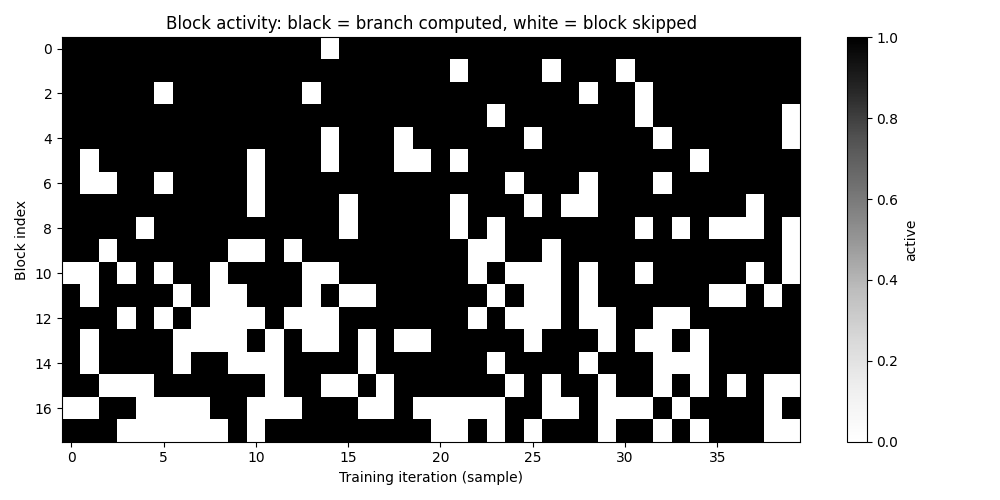

In [9]:
sd_net.train()
num_batches_to_record = 40
activity = np.zeros((sd_net.num_blocks, num_batches_to_record))

hooks = []
def make_hook(block_idx):
    def hook(module, input, output):
        activity[block_idx, hook.call_count] = 1
    hook.call_count = 0
    return hook

hook_fns = []
for i, block in enumerate(sd_net.blocks):
    fn = make_hook(i)
    hook_fns.append(fn)
    hooks.append(block.branch.register_forward_hook(fn))

data_iter = iter(train_loader)
for b in range(num_batches_to_record):
    images, _ = next(data_iter)
    images = images.to(device)
    with torch.no_grad():
        sd_net(images)
    for fn in hook_fns:
        fn.call_count += 1

for h in hooks:
    h.remove()

plt.figure(figsize=(10, 5))
plt.imshow(activity, aspect="auto", cmap="Greys", interpolation="nearest")
plt.xlabel("Training iteration (sample)")
plt.ylabel("Block index")
plt.title("Block activity: black = branch computed, white = block skipped")
plt.colorbar(label="active")
plt.show()

## Overfitting: does stochastic depth actually regularize?

The endpoint numbers above (91.8% vs. 90.3% test accuracy) undersell what's actually going on.
Looking at train vs. test accuracy per model, and at the gap between them, tells a clearer story.

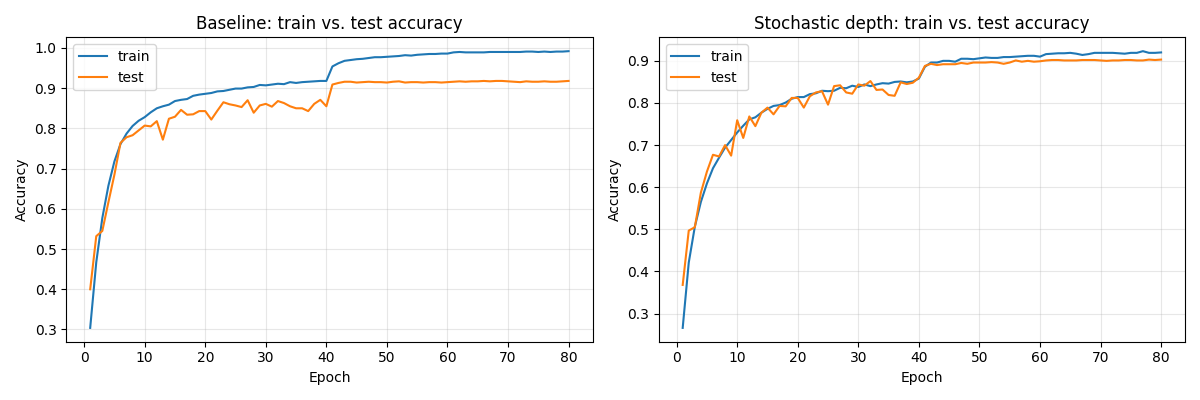

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, baseline_history["train_acc"], label="train")
axes[0].plot(epochs_range, baseline_history["test_acc"], label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline: train vs. test accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, sd_history["train_acc"], label="train")
axes[1].plot(epochs_range, sd_history["test_acc"], label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Stochastic depth: train vs. test accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

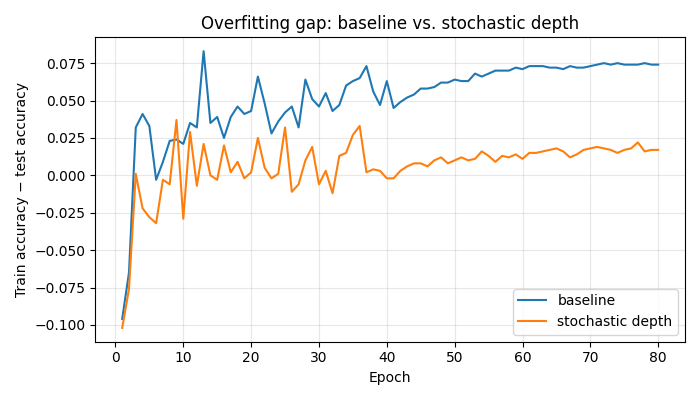

Final overfitting gap - baseline: 0.074, stochastic depth: 0.017


In [ ]:
baseline_gap = [t - v for t, v in zip(baseline_history["train_acc"], baseline_history["test_acc"])]
sd_gap = [t - v for t, v in zip(sd_history["train_acc"], sd_history["test_acc"])]

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, baseline_gap, label="baseline")
plt.plot(epochs_range, sd_gap, label="stochastic depth")
plt.xlabel("Epoch")
plt.ylabel("Train accuracy − test accuracy")
plt.title("Overfitting gap: baseline vs. stochastic depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final overfitting gap - baseline: {baseline_gap[-1]:.3f}, stochastic depth: {sd_gap[-1]:.3f}")

**The takeaway:** baseline keeps improving train accuracy well past the point test accuracy
plateaus (a widening train/test gap = classic overfitting). Stochastic depth's train and test
accuracy stay much closer together throughout — it's not memorizing the training set the same
way, even though it hasn't (yet, at this epoch budget) overtaken baseline on raw test accuracy.
This is the paper's implicit-regularization claim, visible directly in the numbers: each block
effectively sees fewer gradient updates over training, which acts like an ensemble of shallower
networks rather than one very deep one.